<!-- COLAB-BADGE -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB08_SoftwareEngineering.ipynb)  
[Download .ipynb](https://raw.githubusercontent.com/brendanpshea/computing_concepts_python/main/v2/notebooks/COMP1150_NB08_SoftwareEngineering.ipynb) · [View on GitHub](https://github.com/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB08_SoftwareEngineering.ipynb)


📺 **Lecture video:** *(link coming soon)*

## Learning Outcomes

By the end of this notebook, you will be able to:

- **Describe** the stages of the **software development life cycle (SDLC)** and explain why teams plan before they type.
- **Write** a clear **requirement** and **user story** for a feature.
- **Use** **git** to track changes, read a project's history, and recover an earlier version of your work — and **explain** how git is really used day-to-day through GitHub and your code editor.
- **Write** simple **tests** with `assert` to check that code is *correct*, not just that it *runs*.
- **Review** AI-generated code critically — finding bugs and judgment problems *before* they ship.
- **Explain** how software is actually built in 2026, when AI writes much of the code, and **discuss** who is responsible for it.

*Maps to course LOs: 5, 13*

## The Problem: A Wrong Dose Ships to Emerald City Hospital

It is Dorothy's first week as a junior developer at **Emerald City Hospital**. The hospital runs its own software, **MedTrack**, which records the medications each patient receives.

On Tuesday, a nurse reports that MedTrack logged a dose of **5.0 mg** for a patient who should have received **0.5 mg**. Nobody typed the wrong number — the *program* did it. The code "worked": it ran without crashing, it printed a number, it saved to the file. It was just **wrong**.

How does a single bad line of code make it all the way to a real patient? And what do professional teams do to stop it? That question is what this whole notebook is about.

> Writing code that *runs* is only a small part of software engineering. The hard part is making sure it is **correct**, that you can **undo** mistakes, and that a **human stays responsible** — especially now that AI writes so much of the code.

### The Roadmap

This notebook has four parts. Together they tell the story of how a feature goes from idea to something safe enough to ship.

- **The SDLC** — the stages every project moves through, the two rhythms teams use to move through them (**waterfall vs. agile**), and why we don't just start typing.
- **Git & GitHub** — how teams track every change, work in parallel, and recover from mistakes.
- **Testing** — how we check that code is *correct*, not just that it runs.
- **AI-Assisted Development** — how code actually gets written in 2026, and why everything before it matters *more*, not less, when AI writes the first draft.

Our running example is **MedTrack**, the patient-medication tracker.

## The Software Development Life Cycle

The Scarecrow wants a brain — and on a software team, "using your brain" mostly means **thinking before you build**. Rushing straight to code is how a hospital ends up with a 5.0 mg bug.

Professionals describe the journey of any software project as the **software development life cycle (SDLC)** — a sequence of stages a project moves through:

1. **Requirements** — figure out *what* the software must do, and for whom.
2. **Design** — decide *how* it will work: the structure, the pieces, the data.
3. **Build** — actually write the code (this is the part beginners think is the *whole* job).
4. **Test** — check that it does what the requirements said, *correctly*.
5. **Deploy** — release it so real people (nurses, patients) can use it.
6. **Maintain** — fix bugs, add features, adapt as needs change.

The 5.0 mg dose bug is a **requirements-and-test failure** wearing a costume: nobody clearly wrote down the rules for a valid dose, and nobody tested for a bad one.

### Picture It: The Cycle

It's called a *life cycle*, not a *life line*, because software is never really "done." Maintenance feeds new requirements, and the loop starts again. A bug caught at **Requirements** costs a sentence to fix; the *same* bug caught at **Deploy** — in a patient's chart — can cost far more.

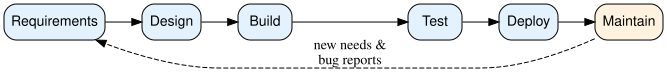

In [ ]:
#| echo: false
#@title 🔄 The SDLC cycle — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr(rankdir="LR")
g.attr("node", shape="box", style="filled,rounded", fillcolor="#e3f2fd",
       fontname="Helvetica")
stages = ["Requirements", "Design", "Build", "Test", "Deploy"]
for s in stages:
    g.node(s, s)
for a, b in zip(stages, stages[1:]):
    g.edge(a, b)
g.node("Maintain", "Maintain", fillcolor="#fff3e0")
g.edge("Deploy", "Maintain")
g.edge("Maintain", "Requirements", label="  new needs &\n  bug reports",
       constraint="false", style="dashed")
g

### Waterfall vs. Agile: Two Ways Around the Loop

Knowing the *stages* doesn't settle the biggest practical question: how should a team move *through* them? Two classic answers dominate software history.

**Waterfall** takes the list literally — finish each stage completely before starting the next. Gather *all* the requirements and sign them off; design *everything*; then build; then test; then deploy. One long pass, like water flowing down a series of falls, with no swimming back up. It feels wonderfully organized. Its famous weakness: you find out whether you built the *right thing* only at the very end, when changing course is most expensive. If the nurses first see MedTrack a year in and say "that's not how we record doses at all," that's a year of work aimed at the wrong target.

**Agile** runs the same stages as *many small loops* instead of one big pass. The team builds a thin slice of working software in a short cycle called a **sprint** (commonly one to four weeks), puts it in front of real users, and lets what they learn *change the requirements* before the next loop. Working software early and often; course corrections while they're still cheap. A bare-bones dose-entry screen that nurses try in week two could surface the 0.5-vs-5.0 confusion before it ever reached a patient.

Neither approach is simply "right":

- **Waterfall still fits** when the requirements truly are fixed and changing the product later is enormously costly — firmware burned into a heart monitor, or software a regulator must approve as one complete, documented package.
- **Agile fits** the far more common case: nobody fully knows the requirements until users touch the software.
- **Most real teams run something agile-ish** — short cycles and feedback at the core, plus as much up-front planning and documentation as the project's risk demands. Hospital software like MedTrack needs both: sprints *and* a paper trail.

Keep this idea in your pocket — a tight loop of *build a little, check it, adjust*. It comes back twice in this notebook: as the test-fix-retest rhythm of the testing section, and again at high speed when an AI writes the first draft.

### Picture It: One Pass vs. Many Loops

The same stages, two rhythms. Waterfall crosses the river in one giant leap; agile crosses on stepping stones, checking its footing at each one.

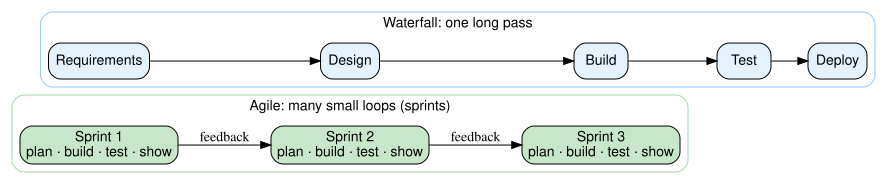

In [ ]:
#| echo: false
#@title 🌊 Waterfall vs. agile — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr(rankdir="LR", fontname="Helvetica")
g.attr("node", shape="box", style="filled,rounded", fontname="Helvetica")

with g.subgraph(name="cluster_a") as a:
    a.attr(label="Agile: many small loops (sprints)", fontname="Helvetica",
           style="rounded", color="#a5d6a7")
    a.attr("node", fillcolor="#c8e6c9")
    for n in ["s1", "s2", "s3"]:
        a.node(n, "Sprint " + n[1] + "\nplan · build · test · show")
    a.edge("s1", "s2", label="  feedback")
    a.edge("s2", "s3", label="  feedback")

with g.subgraph(name="cluster_w") as w:
    w.attr(label="Waterfall: one long pass", fontname="Helvetica",
           style="rounded", color="#90caf9")
    w.attr("node", fillcolor="#e3f2fd")
    stages = ["Requirements", "Design", "Build", "Test", "Deploy"]
    for s in stages:
        w.node("w_" + s, s)
    for a, b in zip(stages, stages[1:]):
        w.edge("w_" + a, "w_" + b)

g

### Requirements: Turning a Wish Into a Spec

"Track medications" is a *wish*, not a plan. A **requirement** is a precise, testable statement of what the software must do. Teams often write requirements as **user stories**, which keep the focus on *who* needs *what* and *why*.

A user story follows a simple shape — fill in the three blanks:

```
As a  <kind of user>,
I want  <some capability>,
so that  <some benefit>.
```

Compare a vague wish with a precise requirement for MedTrack:

- ❌ **Vague:** "The app should handle doses."
- ✅ **Precise:** "A recorded dose must be a positive number between 0.01 and 1000 mg. If it falls outside that range, the app must reject it and show an error instead of saving it."

That second version is something you can actually *build* and *test*. The vague one is how 5.0 mg slips through.

### ✏️ Your Turn — Write a Requirement

Pick one feature MedTrack might need (for example: searching for a patient, recording who gave a dose, or warning about a drug interaction).

In the cell below, fill in:

1. **One user story** using the `As a... I want... so that...` shape.
2. **One precise, testable requirement** for that feature — specific enough that someone could later check whether the code obeys it.

There's no autograder here; just edit the text.

> **✏️ Write your answer here.** Double-click this cell to edit it, fill in the blanks, then press **Shift+Enter** to render it. (This is writing, not code — no `print` needed.)
>
> **User story**
> As a \_\_\_,
> I want \_\_\_,
> so that \_\_\_.
>
> **Precise, testable requirement**
> \_\_\_

### 💭 Think About It — Skipping the Plan

Beginners (and rushed teams) love to skip straight to the **Build** stage — it feels productive to be typing code.

1. Why might jumping straight to writing code *feel* faster but actually end up *slower* for a real project?
2. Think of a non-software project you've done where poor planning caused problems later (an essay, a road trip, an event). What did the "requirements" stage look like — or what happened because there wasn't one?
3. In a hospital, who *besides programmers* should have a say in the requirements for MedTrack? Why does that matter?
4. MedTrack is hospital software: mistakes can reach patients, and regulators may demand documented evidence before anything ships. Make the best case you can for running this project **waterfall**, then the best case for **agile**. Which would you actually choose — and what would you borrow from the other approach?

## The Cowardly Lion's Problem

The Cowardly Lion is afraid to touch MedTrack's code. What if he changes something and breaks the whole thing? What if he can't get back to the version that worked?

This fear is completely reasonable — and **version control** is the cure. A version-control tool records the full history of a project: every change, who made it, when, and why. If today's edit breaks something, you can look back, compare, and return to any earlier version. The Lion can finally experiment without dread.

The standard tool for this, used almost everywhere, is **git**.

## What Version Control Is

A **version-control system** records the full history of a project: every change, who made it, when, and *why*. Think of it as an unlimited, organized "undo" that works across the whole project and never forgets.

The core idea is the **commit** — a saved **snapshot** of the project at one moment, with a short message describing the change ("Reject doses outside the safe range"). String the commits together and you get the project's **history**: a timeline you can read, compare, and **return to**. Made a mess today? You can look back at yesterday's snapshot and restore it. That's what finally lets the Cowardly Lion experiment without fear.

The standard tool for this — used almost everywhere — is **git**. The most popular place to store git projects online, so a whole team can share them, is **GitHub**.

### Picture It: The Three Areas

When you save work with git, a change moves through three places: the **working directory** (the files you edit), the **staging area** (the changes you've chosen to include next), and the **repository** (the permanent history of snapshots). The diagram below shows that one-way flow.

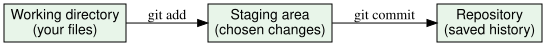

In [ ]:
#| echo: false
#@title 🗂️ Git's three areas — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr(rankdir="LR")
g.attr("node", shape="box", style="filled", fillcolor="#e8f5e9",
       fontname="Helvetica")
g.node("W", "Working directory\n(your files)")
g.node("S", "Staging area\n(chosen changes)")
g.node("R", "Repository\n(saved history)")
g.edge("W", "S", label="  git add")
g.edge("S", "R", label="  git commit")
g

### The Commands Under the Hood

You won't run these in this notebook — in a moment you'll use GitHub's website instead, which is friendlier. But it's worth seeing the actual commands once, because every button you'll click is secretly running one of them. The basic rhythm for saving work is three commands:

```
git init                       # start tracking the current folder as a repo
git add  <files>               # stage the changes you want in the next snapshot
git commit -m "<message>"      # save the snapshot, with a note explaining it
```

To look back, you'd use `git log` to read the history and `git show` (or `git checkout`) to view or restore an earlier snapshot. The message on each commit matters: *"fixed the dose validation bug"* tells a future teammate (or future you) **why** the change happened — *"stuff"* tells them nothing.

So when GitHub later shows you a "commit" or a list of past versions, it's not magic — it's exactly these commands wearing a nicer outfit.

### Recovering an Earlier Version

Here's the payoff that cures the Lion's fear. Because *every* commit is kept, you can always look at — or restore — any earlier version of any file, even one from weeks ago. If today's change breaks MedTrack, you don't panic: you open the history, find the last snapshot that worked, and bring it back. Nothing good is ever truly lost once it's been committed.

### How You'll *Really* Use Git: GitHub & Your Editor

Here's the honest truth about working life: **most developers rarely type those commands by hand.** Git almost always runs underneath friendlier tools:

- **GitHub** (and GitLab, Bitbucket) — websites that store the shared, official copy of a project online so a whole team can collaborate. This is also where **code review** happens — and it's what you'll set up in this notebook's exercise.
- **Your code editor / IDE** — editors like **VS Code** have a built-in "Source Control" panel with buttons for the common actions, so you click instead of type.
- **GitHub Desktop** — a standalone app that wraps git in a simple window.

You learned the commands above for the same reason you learn arithmetic before trusting a calculator: when something goes wrong (and with git, eventually it will), the people who understand what's *actually happening* are the ones who can fix it.

### Branches, Pull Requests & Code Review

Teams add three more ideas on top of commits. You don't need to run them now, but you'll meet them on any real project:

- **Branch** — a separate, safe copy of the project's timeline where you build a feature *without* touching the working version everyone depends on. The Lion can experiment on a branch and break nothing real.
- **Pull request (PR)** — when the feature is ready, you open a pull request: a formal "please review and merge my changes" proposal.
- **Code review** — before the PR is merged, a teammate reads it. Glinda, the senior engineer, checks Dorothy's code for bugs and problems *before* it reaches a patient. Only after approval does it **merge** into the main project.

This review step is one of the most important safety nets in all of software — and when we get to AI-assisted development we'll see it's *exactly* what we need when an AI writes the code.

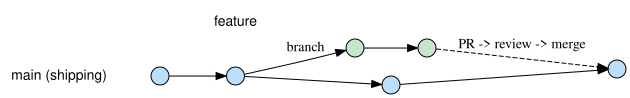

In [ ]:
#| echo: false
#@title 🌿 Branch, pull request & merge — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr(rankdir="LR")
g.attr("node", shape="circle", width="0.25", label="", style="filled",
       fontname="Helvetica")

# main line (trusted, shipping version)
g.attr("node", fillcolor="#bbdefb")
for n in ["m1", "m2", "m3", "m4"]:
    g.node(n)
g.edge("m1", "m2"); g.edge("m2", "m3"); g.edge("m3", "m4")

# feature branch
g.attr("node", fillcolor="#c8e6c9")
for n in ["f1", "f2"]:
    g.node(n)
g.edge("m2", "f1", label="  branch")
g.edge("f1", "f2")
g.edge("f2", "m4", label="  PR -> review -> merge", style="dashed")

g.node("mainlbl", "main (shipping)", shape="plaintext", fillcolor="white")
g.node("featlbl", "feature", shape="plaintext", fillcolor="white")
g.edge("mainlbl", "m1", style="invis")
g.edge("featlbl", "f1", style="invis")
g

## ✏️ Your Turn — Set Up GitHub and Save This Notebook

This is the hands-on part — and you'll do it **in your browser**, not in a code cell, because that's how version control really works. You'll come away with a real GitHub account and a class repository holding your own copy of this notebook.

> 💡 GitHub's and Colab's screens change their wording from time to time, so the exact button labels may look a little different from what's written here — the steps and the order stay the same.

**1. Create a free GitHub account.**
Go to **[github.com](https://github.com)** and sign up. You'll need an email address and a username (pick something you wouldn't mind a future employer seeing). It's free. As a student, you can also unlock extra free tools later through the **[GitHub Student Developer Pack](https://education.github.com/pack)**.

**2. Create a repository for this class.**
Once signed in, click the **+** in the top-right corner and choose **New repository**. Name it something like `comp1150`, set it to **Private** (this is your personal class space), check **Add a README file**, and click **Create repository**. You now have a repo — a home for this course's work.

**3. Save *this* notebook into your repo.**
You're reading this in Google Colab, which can save straight to GitHub. In the Colab menu choose **File → Save a copy in GitHub**. The first time, it will ask permission to connect to your GitHub account — approve it. Then pick your `comp1150` repository, keep the default filename, and click **OK**. Colab just made your first **commit** for you.

> 💡 *Not in Colab?* Plain Jupyter has no "Save a copy in GitHub" menu. No problem: download the notebook (**File → Download**), then in your repo on github.com click **Add file → Upload files** and upload it. Different door, same result — a commit.

**4. See your history grow.**
Back on GitHub, open your `comp1150` repo and click your saved notebook. Now make a tiny change here in Colab — for example, type your name in the cell below — and do **File → Save a copy in GitHub** again. Refresh the repo page and click the **commits** link (it shows a clock/history icon). You should see **two** commits: proof that GitHub kept *both* versions and you could return to either one. That history is the whole point.

> **✏️ Your name here:** \_\_\_  *(Double-click to edit, then re-save the notebook to GitHub in step 4.)*

### 💭 Think About It — The Audit Trail

Because of git, Emerald City Hospital can see *exactly* who changed each line of MedTrack, when, and why.

1. Why does a complete, permanent history of changes matter *more* for hospital software than for, say, a hobby video game?
2. If the 5.0 mg dose bug reached a patient, how could the project's git history help the team figure out what went wrong — and who needs to be part of the fix?
3. Knowing that every change is permanently recorded with your name on it, how might that change the way a developer works? Is that pressure a good thing, a bad thing, or both?

## The Tin Woodman's Standard

The Tin Woodman wants to do things *right*. For software, "right" has a specific meaning that trips up almost every beginner:

> **Code that runs is not the same as code that is correct.**

The original 5.0 mg bug ran perfectly. It crashed nothing. It just produced the *wrong answer*. The only way to catch that kind of problem on purpose — before a patient does — is to **test**: feed the code known inputs and check that it produces the answers you expect.

### The Syntax of `assert`

The simplest testing tool in Python is the `assert` statement. You give it something that should be **True**. If it is, nothing happens and the program moves on. If it is **False**, Python stops immediately and raises an `AssertionError` — a loud, deliberate alarm.

```
assert <something that should be True>
assert <something that should be True>, "<message if it's False>"
```

That optional message after the comma is what gets shown when the check fails, so make it describe what went wrong.

### Hands-On: Testing a Simple Function

Here's a small MedTrack helper that converts a dose in grams to milligrams. Let's write `assert` checks that pin down what "correct" means for it.

In [ ]:
def grams_to_mg(grams):
    """Convert a dose in grams to milligrams."""
    return grams * 1000

# Each assert states a fact that MUST be true if the function is correct.
assert grams_to_mg(1) == 1000,   "1 g should be 1000 mg"
assert grams_to_mg(0.5) == 500,  "0.5 g should be 500 mg"
assert grams_to_mg(0) == 0,      "0 g should be 0 mg"

print("All checks passed ✅")

All checks passed ✅


### A Bug Hides in Plain Sight

Now meet a function that **runs fine** but is **wrong**. It's supposed to round a dose to one decimal place. Read it, then run the tests below it.

In [ ]:
def round_dose(mg):
    """Round a dose to 1 decimal place (e.g., 0.46 -> 0.5)."""
    return round(mg)          # <-- bug: forgot the number of decimal places!


In [ ]:
# These tests describe what "correct" means. Run this cell — and watch the test catch the bug.
assert round_dose(0.46) == 0.5, "0.46 mg should round to 0.5, got " + str(round_dose(0.46))
print("All checks passed ✅")

AssertionError: 0.46 mg should round to 0.5, got 0

### Understanding the Failure

Run the cell above and you'll get an **`AssertionError`** showing the message we wrote. That failure is a *success* for us — the test caught a real bug before any patient did. Notice what happened:

- `round(0.46)` returns `0` (rounds to the nearest *whole* number).
- We wanted `round(0.46, 1)` — round to *one decimal place* — which gives `0.5`.

This is exactly the flavor of mistake behind the opening 5.0 mg disaster: code that runs, looks reasonable, and is quietly wrong. A test turned a silent error into a loud one.

### ✏️ Your Turn — Catch and Fix the Bug

Below is the buggy `round_dose` again.

1. **First**, add one or two more `assert` checks describing correct behavior (for example, `round_dose(1.24)` should be `1.2`).
2. **Then** fix the function body so all your checks pass.

In [ ]:
def round_dose(mg):
    """Round a dose to 1 decimal place."""
    return round(mg)          # TODO: fix this line

# TODO: add a couple of assert checks for correct behavior, e.g.:
# assert round_dose(1.24) == 1.2, "1.24 should round to 1.2"


print("If you see this with no error, your checks passed ✅")

If you see this with no error, your checks passed ✅


### Picture It: The Testing Mindset

Professionals often write the **test first** — stating what "correct" means — and only then write or fix the code until the test passes. Once a test exists, it keeps guarding that behavior forever: if a future change re-breaks it, the test fails again instantly, catching a **regression** (an old bug coming back).

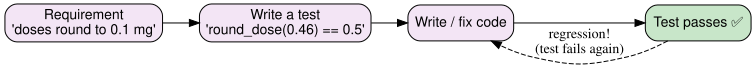

In [ ]:
#| echo: false
#@title ✅ The test-first loop — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr(rankdir="LR")
g.attr("node", shape="box", style="filled,rounded", fillcolor="#f3e5f5",
       fontname="Helvetica")
g.node("R", "Requirement\n'doses round to 0.1 mg'")
g.node("T", "Write a test\n'round_dose(0.46) == 0.5'")
g.node("C", "Write / fix code")
g.node("P", "Test passes ✅", fillcolor="#c8e6c9")
g.edge("R", "T"); g.edge("T", "C"); g.edge("C", "P")
g.edge("P", "C", label="  regression!\n  (test fails again)",
       style="dashed", constraint="false")
g

### 💭 Think About It — "It Ran Without Errors"

1. In your own words, what's the difference between code that *runs* and code that is *correct*? Give an everyday (non-coding) example of something that "worked" but was still wrong.
2. You can never test *every* possible input. So how does a team decide which tests are worth writing? What kinds of inputs are most likely to hide bugs?
3. For software that affects people's health, is "we tested it and it passed" ever *enough* to be sure it's safe? What else might matter?

## How Code Really Gets Written in 2026

You already know an AI can write code — you've been doing it all semester. So this section isn't about *that*. It's about the harder, more valuable skill: how to **engineer** with an AI rather than just prompt it. Asking an assistant for a single function is easy. Building something real — something you'd trust at Emerald City Hospital — takes discipline the AI can't supply for you.

That discipline is the great-and-powerful **Wizard of Oz** lesson. The Wizard is dazzling and confident — and when Toto pulls back the curtain, *just a man pulling levers*. An AI assistant produces text that *reads* like expert code. Whether it is actually correct, safe, and appropriate is a separate question — and answering it is now **your** job. The modern loop is:

1. **You decompose and spec** — decide what pieces should exist and describe them clearly.
2. **The AI drafts** — fast, fluent, often *mostly* right.
3. **You review, test, and own it** — because plausible is not the same as correct, and your name is on it.

The punchline of this whole notebook: **AI writing the code makes planning, version control, and testing more important, not less.** The human stopped being the typist and became the one who is *responsible*.

### Decomposition — You Draw the Boxes

Here's the part an AI *won't* do for you. The hard part of a real program isn't writing a function — it's deciding **what functions should exist** and how they fit together. The AI is brilliant at filling in a box you've defined. Drawing the boxes is the engineer's job.

One decomposition decision matters more than any other for *quality*: **separate the pure logic from the input/output.**

- **Pure logic** — the rules. Given some inputs, it computes an answer and returns it (no printing, no asking). A function like "given the secret code and a guess, how many symbols are correct?" is pure logic.
- **Input / output (I/O)** — the parts that talk to the human: `input()` to read a guess, `print()` to show feedback, the loop that runs the game.

Why split them? Because **you can only write `assert` tests against pure logic.** You can't easily test code that stops to ask a human a question, but you *can* test a function that takes inputs and returns an answer. So designing your program with a testable logic core isn't just tidy — it's what makes the rest of this notebook's discipline *possible*.

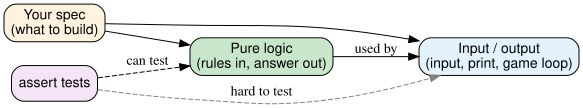

In [ ]:
#| echo: false
#@title 🧩 Pure logic vs. I/O — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr(rankdir="LR")
g.attr("node", shape="box", style="filled,rounded", fontname="Helvetica")
g.node("spec", "Your spec\n(what to build)", fillcolor="#fff3e0")
g.node("logic", "Pure logic\n(rules in, answer out)", fillcolor="#c8e6c9")
g.node("io", "Input / output\n(input, print, game loop)", fillcolor="#e3f2fd")
g.node("tests", "assert tests", fillcolor="#f3e5f5")
g.edge("spec", "logic")
g.edge("spec", "io")
g.edge("logic", "io", label="  used by")
g.edge("tests", "logic", label="  can test", style="dashed")
g.edge("tests", "io", label="  hard to test", style="dashed", color="gray")
g

### The Spec Is the Real Source Code

When you build with AI, something quietly flips. In the old world, the **code** was the thing you wrote and treasured. In the AI world, the code is *downstream* — the AI can regenerate it any time. What you actually author, refine, and keep is the **spec**: the clear description of what the program must do.

This is why everything from the start of the notebook pays off here. A vague request gets vague, buggy code; a precise spec — inputs, rules, edge cases, constraints — gets code worth keeping. Your prompt to an AI *is* a spec. Writing a good one is the same skill as writing a good requirement, just aimed at a machine.

### Iterative Development: The First Draft Is Rarely Right

Beginners treat the AI's first answer as *the* answer. Professionals treat it as a **first draft**. Real AI-assisted development is a conversation: you read the draft, find what's wrong or missing, and ask for a fix — then check *that* too. The skill is steering: knowing what to ask for next, and knowing when to stop steering and just fix the two lines yourself.

And every loop needs a way to tell whether the new draft is *actually* better. That's what your tests are for. Without them, "fixing" one thing while the AI silently breaks another is just spinning in circles.

Notice what this loop *is*: the **agile** cycle from the start of this notebook, shrunk from weeks to minutes. Every prompt-review-fix round is a tiny sprint — build a little, check it, adjust — with you playing the customer who gives the feedback.

### Reading AI Code Critically

An AI assistant is built to produce **plausible** text — output that *reads* like a confident expert wrote it. But **plausible is not the same as correct.** AI-generated code can:

- contain subtle logic bugs (an off-by-one, a wrong rounding) that look perfectly normal;
- call functions or libraries that don't actually exist (a "hallucination");
- ignore a rule you forgot to state;
- do something *technically* working but *inappropriate* — like leaking private patient data.

So you read every line and ask: *Does this match the spec? What happens with bad input? Is anything here unsafe?* This is the same **code review** skill from before — now aimed at a machine's output.

### 🔍 The Curtain Exercise — Review the Wizard's Code

The Wizard (our AI assistant) was asked to write a function that records a patient's dose. Here's what it produced. It's clean, it's confident, and it **runs**. Your job is to be **Glinda**: review it *before* it ships and find what's wrong.

Read the function carefully first. There are (at least) **two** problems hiding in it — one a *bug*, one a *judgment/privacy* issue.

In [ ]:
# --- Code drafted by the AI assistant (the "Wizard"). Review before shipping! ---

def record_dose(patient_name, mg):
    """Record a patient's medication dose."""
    # Reject doses outside the safe range.
    if mg < 0.01 or mg > 1000:
        print("Dose out of range")

    # Save a log line so we have a record.
    with open("public_dose_log.txt", "a") as f:
        f.write(patient_name + " received " + str(mg) + " mg\n")

    return "Dose recorded for " + patient_name

# It runs without crashing -- which is exactly the trap.
print(record_dose("Aunt Em", 5000))

Dose out of range
Dose recorded for Aunt Em


### Understanding What We Caught

Run the cell above and watch the trap spring: `record_dose("Aunt Em", 5000)` is **way** over the safe limit, yet the function happily returns `"Dose recorded for Aunt Em"`. Here are the two problems:

1. **A correctness bug.** When the dose is out of range, the code only `print`s a warning — then *keeps going* and records the dose anyway. It should **stop** (e.g., `raise ValueError`) so a bad dose is never saved. A **test** like `assert`-checking that 5000 mg is rejected would have caught this instantly.

2. **A privacy / judgment problem.** It writes the **patient's name** into a file literally named `public_dose_log.txt`. Even if every line *worked*, dumping identifiable patient data into a shared/public file is a serious violation. **No test would catch this** — it takes a *human* who understands the hospital's rules and values.

That second point is the heart of the notebook: some problems are caught by tests, but others can only be caught by a responsible person who knows the context. The Wizard can draft; only Glinda can approve.

### 💭 Think About It — Who Is Responsible?

1. The Wizard's function had a dangerous bug *and* a privacy violation, but it was an AI that "wrote" it. If that code reached a patient, **who is responsible** — the AI, the developer who accepted it, the reviewer, the hospital? Defend your answer.
2. What does it mean to **"own" code you didn't personally type**? Is accepting AI-written code more like (a) hiring a contractor, (b) copying a classmate's homework, or (c) using a calculator? Argue for the best analogy.
3. Should an AI assistant be allowed to write code that controls **medication dosing** at all? If yes, what safeguards would you require first? If no, where exactly is the line?

### 💭 Think About It — Using AI in *This* Course

You have access to the same kind of AI assistant the pros use. That raises a real question about your own learning.

1. Where's the line between **learning *with* AI** (it helps you understand) and **outsourcing your learning** (it does the thinking so you don't have to)? Give a concrete example of each.
2. If an AI can write the code for an assignment in seconds, what is the *actual skill* this course is trying to build in you? Has this notebook changed your answer?
3. Imagine you're hiring a junior developer in 2026. Knowing AI writes much of the code, what would you most want to test that a candidate can do? How might you find out?

## ✏️ Capstone — Crack the Emerald Gate Code

Time to run the *whole* engineering loop yourself, on something bigger than a single function: you'll build a small game with an AI assistant. The point isn't a polished game — it's experiencing **why** specs, tests, and version control exist by actually needing them.

Unlike earlier notebooks, **you write every prompt.** The notebook tells you *what* to build and *what good looks like*; composing the prompts to Gemini, Claude, or ChatGPT is your job (and you're free to re-theme the game however you like).

### First: What Game Are We Building?

The **Gatekeeper of the Emerald City** picks a secret code of **4 colored gems**, chosen from 6 colors (repeats allowed). On each turn the player guesses 4 gems, and the game gives two clues:

- how many gems are the **right color in the right position**, and
- how many are the **right color but in the wrong position**.

The player uses those clues to deduce the code, and wins by cracking it within **10 guesses**. Here's a short sample so the idea is unmistakable:

```
Secret (hidden):  🟥 🟩 🟩 🟦

Guess 1: 🟥 🟦 🟨 🟩   ->  1 right spot, 2 right color / wrong spot
Guess 2: 🟥 🟩 🟦 🟩   ->  3 right spot, 1 right color / wrong spot
Guess 3: 🟥 🟩 🟩 🟦   ->  4 right spot  --  cracked it! 🎉
```

That's the entire game. (This is the classic game *Mastermind*; the colored-gem version just gives it an Emerald City coat of paint.)

### Step 1 — Build the Whole Game *(prompt #1)*

Write **one** prompt that asks your AI assistant to build the complete game described above, and paste its code into the cell below, then play it.

Your prompt should make the spec precise — the things *you* now know to include:
- the rules exactly as above (4 gems, 6 colors, repeats allowed, two clue numbers, 10 guesses, win/lose);
- **one specific instruction that pays off in Step 2:** ask for the scoring to live in its own function, e.g. `score_guess(secret, guess)` that *returns* the two clue numbers (right-spot, wrong-spot) — separate from the `input`/`print` game loop. (Remember: pure logic you can test; I/O you can't.)
- **two notebook-survival instructions**, because this code will live in a notebook cell, not a `.py` file:
  - the player **types letters** for the colors (e.g. `R G B Y P O`) — emoji are fine to *display*, but nobody can type 🟥 into an input box;
  - the game loop lives in a function `play()` that is **not called automatically** — tell the AI: no `play()` call and no `if __name__ == "__main__":` block at the bottom. (In a notebook that block runs anyway, and the game would demand input every single time you re-ran the cell — including later, when all you want is to re-define `score_guess` for testing.) You'll start the game yourself in the next cell.

In [ ]:
# Paste the AI's game code here — function definitions only, with NOTHING at the
# bottom that calls play() automatically. Run this cell once to define the game.


In [ ]:
# Now play! Remove the # from the line below and run this cell. (Keeping play()
# in its own cell means re-running the definitions above never traps you in the game.)
# play()

### Step 2 — Add Tests *(prompt #2)*

Don't trust the draft — pin it down. Write a prompt asking the AI to produce `assert` tests for the `score_guess` function. Paste them below and run them.

Make sure your prompt demands the case that trips up almost every first draft: **repeated colors.** For example, if the secret is `🟥🟥🟩🟦` and the guess is `🟥🟦🟥🟥`, a naive scorer double-counts the extra red gems and reports the wrong-spot number incorrectly. A good test catches that. If a test fails, you've found a real bug — fix it (or re-prompt) until they pass.

One more notebook-survival instruction for your prompt: ask for the tests **wrapped in a function** — `run_tests()` — that runs every `assert` and finishes with a line like `print("All tests passed ✅")`. That way Step 4 can re-run the whole suite with a single call.

In [ ]:
# Paste the AI's tests here: a run_tests() function full of asserts.
# Then remove the # below and run the cell — a failure means a real bug. Fix it!
# run_tests()

### Step 3 — Extend the Game *(prompt #3)*

Now grow it. Write a prompt asking the AI to add **one** new feature to your game. Pick one (or invent your own):

- a **hint** the player can request (reveals one gem);
- **difficulty levels** that change the code length or number of colors;
- also report the **total number of correct-color gems** each turn.

Paste the AI's new, extended version of the game below.

In [ ]:
# Paste the AI's extended version of the game here.


### Step 4 — Regression Test

Here's the payoff. Re-run your Step 2 tests against the **extended** code from Step 3.

When an AI rewrites a program to add a feature, it often quietly breaks something that used to work — that's a **regression**. Your tests are exactly what catch it. First **re-run the Step 3 cell**, so the *extended* `score_guess` is the one currently defined — then run the cell below: the same `run_tests()` from Step 2, now aimed at the new code.

- If the tests still pass: great — your change was safe.
- If a test now **fails**: the AI broke your scoring while adding the feature. *That's the lesson.* Diagnose it, fix it (or re-prompt), and get back to green before you'd ever ship.

In [ ]:
# 1. Re-run the Step 3 cell, so the EXTENDED score_guess is the one defined.
# 2. Remove the # below and run — same tests, new code. That's a regression test.
# run_tests()

### Ship It — Save to GitHub

You took a real program through the full loop: spec, AI draft, tests, an extension, a regression caught and fixed. Now save your work the way you set up earlier: **File -> Save a copy in GitHub -> your `comp1150` repo.** That's a real commit, in your real history — with a game in it you can actually play. *(Plain Jupyter: download the notebook, then **Add file → Upload files** in your repo on github.com — same commit, different door.)*

## Key Terms

- **Software development life cycle (SDLC)** — the stages a software project moves through: requirements, design, build, test, deploy, maintain.
- **Waterfall** — running the SDLC stages as one long pass: finish each stage completely before the next; feedback arrives only at the end.
- **Agile** — running the SDLC as many short loops, shipping a small working slice each time and letting feedback change the requirements.
- **Sprint** — one short agile cycle (commonly 1–4 weeks) that ends with working software and user feedback.
- **Requirement** — a precise, testable statement of what software must do.
- **User story** — a requirement written from a user's view: "As a …, I want …, so that …."
- **Version control** — a system that records the full history of changes to a project.
- **Git** — the most widely used version-control tool.
- **Repository (repo)** — a project tracked by git, including its complete history.
- **Commit** — a saved snapshot of the project, with a message describing the change.
- **Staging area** — the holding zone (`git add`) for changes you've chosen to include in the next commit.
- **GitHub** — a website that hosts the shared copy of a git project and is where teams collaborate and review code.
- **Branch** — a separate timeline for building a change without affecting the main version.
- **Pull request (PR)** — a proposal to merge a branch's changes, used to request review.
- **Code review** — a teammate reading proposed changes before they're merged.
- **Test** — code that checks other code produces the expected result.
- **Assertion (`assert`)** — a statement that raises an error if a condition that should be true is false.
- **Decomposition** — breaking a program into well-defined pieces (deciding *what functions should exist*); the engineer's job, not the AI's.
- **Pure logic vs. I/O** — separating the rules (inputs in, answer out — testable) from the parts that talk to a human (`input`/`print` — hard to test).
- **Spec** — the precise description of what to build; in AI-assisted work it is the real artifact you author and keep, while the code is downstream.
- **Iterative development** — treating the AI's output as a *first draft* and improving it through a review-and-refine loop.
- **Regression** — working code that breaks because of a later change (such as adding a feature); tests are what catch it.
- **Prompt** — the instructions given to an AI assistant; effectively a spec.
- **Hallucination** — confident AI output that is wrong or invented (e.g., a nonexistent function).
- **Accountability** — the principle that a responsible human owns the code, even when an AI drafted it.

## Summary

- **The SDLC.** Software moves through stages — requirements, design, build, test, deploy, maintain. Catching a problem early (in a *requirement*) is far cheaper than catching it late (in a *patient's chart*). Clear requirements and user stories are how vague wishes become buildable, testable plans. Teams move through the stages either as one long pass (**waterfall**) or as many short, feedback-driven loops called sprints (**agile**) — and most modern teams work in short loops.
- **Git & GitHub.** Version control records every change, so teams can collaborate, work in parallel on branches, recover earlier versions, and keep an audit trail. You type git commands to understand them, but day-to-day they live inside GitHub and your editor. Pull requests and code review are the safety net before code ships.
- **Testing.** Code that *runs* is not code that is *correct*. Tests (`assert`) turn silent wrong answers into loud failures, and guard against regressions forever after.
- **AI-Assisted Development.** In 2026, AI drafts much of the code, but it produces *plausible* output, not guaranteed-correct output. The human's job is the engineering *around* it: **decomposing** the problem and writing a clear **spec**, then **iterating** on the draft and holding it to **tests** you own. Some flaws a test catches; others — like a privacy violation — only a responsible human can.

The throughline: **the more code AI writes, the more the human disciplines of this notebook — planning, version control, testing, and judgment — matter.**

## What's Next

**Notebook 9 — Databases: Relational & Non-Relational.** MedTrack has to *store* all those patient records somewhere safe and searchable. Next we'll see how real applications keep data organized, find it fast, and keep it consistent — the foundation under almost every program that matters.